In [1]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(segmented)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: MASS

Warning message:
“package ‘MASS’ was built under R version 4.3.3”

Attaching package: ‘MASS’


The following object is masked from ‘package:dplyr’:

    select


Loading required package: nlme

Warning message:
“package ‘nlme’ was built under R version 4.3.3”

Attaching package: ‘nlme’


The following object is masked from ‘package:dplyr’:

    collapse




In [12]:
load("/vol/projects/yzhang/500FG_aging/output/14_AA/immune_aging_trajectory_calculated_gender.Rdata")

In [11]:
merge_data <- read.csv("/vol/projects/yzhang/500FG_aging/output/14_AA/500fg_heatmap_merge_data_gender.csv",row.names=1)
head(merge_data)
dim(merge_data)
sum(is.na(merge_data))

,Sample_ID,Age,IFNy_C.conidiaHK_WB_48h,IL6_PHA_WB_48h,IL6_C.albicanshyphae_PBMC_24h,IL6_A.fumigatusconidiaSerum_PBMC_24h,IFNy_B.burgdorferi_PBMC_7days,IFNy_Borreliamix_PBMC_7days,IFNy_C.albicansconidia_PBMC_7days,IFNy_C.albicanshyphae_PBMC_7days,⋯,CXCL10,CCL28,CD40,MCP_2,CASP_8,CCL25,CX3CL1,TNFRSF9,NT_3,TNFB
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV001,HV001,27,8.965784,13.03480,7.285402,9.876517,12.287712,5.357552,7.614710,8.149747,⋯,8.36986,1.84040,11.44100,7.99089,2.57231,5.36536,5.09046,6.45090,2.70225,4.44519
HV002,HV002,26,9.511753,12.81238,8.280771,9.712527,8.049849,7.734710,5.882643,6.845490,⋯,8.15846,1.78795,11.19810,8.41194,3.22599,5.76616,5.44641,6.73492,2.76555,4.81664
HV003,HV003,24,5.857981,12.62708,NA,NA,11.421539,9.216746,5.285402,5.807355,⋯,10.09625,1.76763,12.02764,7.39405,3.19766,5.16156,6.08994,6.77356,2.77692,5.64723
HV004,HV004,20,5.285402,13.11586,NA,NA,12.287712,8.607330,5.285402,7.055282,⋯,9.09970,1.16293,10.88593,7.98752,2.42345,6.31634,5.59638,6.68823,2.44064,5.96514
HV005,HV005,22,5.700440,12.66977,7.426265,7.851749,6.569856,9.743151,5.857981,5.832890,⋯,8.56685,2.21728,11.60948,7.83547,3.95433,5.81332,6.07405,7.26541,2.69546,5.17238
HV006,HV006,24,5.781360,12.06205,NA,NA,12.287712,8.924813,5.491853,7.936638,⋯,9.55948,1.79223,11.02686,8.27947,2.93375,5.02830,6.00473,7.15083,2.69737,5.08267


[1] 407  58

[1] 146

In [13]:
cn <- colnames(merge_data)
cytokine <- merge_data[, match("IFNy_C.conidiaHK_WB_48h", cn):match("IL22_Bacteroides_PBMC_7days", cn)]
protein  <- merge_data[, (match("IL22_Bacteroides_PBMC_7days", cn) + 1):ncol(merge_data)]
head(cytokine)
dim(cytokine)
head(protein)
dim(protein)

,IFNy_C.conidiaHK_WB_48h,IL6_PHA_WB_48h,IL6_C.albicanshyphae_PBMC_24h,IL6_A.fumigatusconidiaSerum_PBMC_24h,IFNy_B.burgdorferi_PBMC_7days,IFNy_Borreliamix_PBMC_7days,IFNy_C.albicansconidia_PBMC_7days,IFNy_C.albicanshyphae_PBMC_7days,IFNy_MTB_PBMC_7days,IFNy_S.aureus_PBMC_7days,IFNy_Bacteroides_PBMC_7days,IL17_Bacteroides_PBMC_7days,IL22_B.burgdorferi_PBMC_7days,IL22_Borreliamix_PBMC_7days,IL22_C.albicansconidia_PBMC_7days,IL22_C.albicanshyphae_PBMC_7days,IL22_MTB_PBMC_7days,IL22_S.aureus_PBMC_7days,IL22_Bacteroides_PBMC_7days
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV001,8.965784,13.03480,7.285402,9.876517,12.287712,5.357552,7.614710,8.149747,5.643856,6.303781,7.022368,8.550747,14.28771,10.14720,10.900112,11.40514,10.342075,8.290019,8.290019
HV002,9.511753,12.81238,8.280771,9.712527,8.049849,7.734710,5.882643,6.845490,6.066089,7.276124,9.308339,8.214319,12.32867,12.07915,9.527477,10.02375,10.389094,7.434628,10.594325
HV003,5.857981,12.62708,NA,NA,11.421539,9.216746,5.285402,5.807355,6.700440,9.264443,10.294621,8.581201,14.10558,11.71296,8.679480,10.75238,11.563196,9.361944,11.640697
HV004,5.285402,13.11586,NA,NA,12.287712,8.607330,5.285402,7.055282,5.285402,8.980140,12.202430,6.285402,14.28771,13.72249,8.800900,10.42206,11.369052,10.174926,11.611486
HV005,5.700440,12.66977,7.426265,7.851749,6.569856,9.743151,5.857981,5.832890,7.055282,10.326429,7.033423,7.459432,10.10591,11.45430,10.149747,10.16491,NA,NA,NA
HV006,5.781360,12.06205,NA,NA,12.287712,8.924813,5.491853,7.936638,7.857981,9.632995,12.255029,9.197217,14.28771,11.98050,10.506803,10.07146,9.501837,8.721099,10.087463


[1] 407  19

,IL8,VEGFA,CD8A,CDCP1,OPG,LAP_TGF_beta_1,IL6,MCP_1,CXCL11,CXCL9,⋯,CXCL10,CCL28,CD40,MCP_2,CASP_8,CCL25,CX3CL1,TNFRSF9,NT_3,TNFB
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV001,3.63611,9.48365,9.52098,2.30522,9.68034,6.69739,2.65429,10.45254,7.44738,6.02191,⋯,8.36986,1.84040,11.44100,7.99089,2.57231,5.36536,5.09046,6.45090,2.70225,4.44519
HV002,4.31364,9.69720,10.49119,1.97309,10.23258,7.63274,2.01410,10.74596,7.27919,6.03007,⋯,8.15846,1.78795,11.19810,8.41194,3.22599,5.76616,5.44641,6.73492,2.76555,4.81664
HV003,4.06539,10.19810,9.57446,2.28619,10.33496,7.45751,3.37359,10.71738,7.45611,6.76316,⋯,10.09625,1.76763,12.02764,7.39405,3.19766,5.16156,6.08994,6.77356,2.77692,5.64723
HV004,3.20146,9.97967,7.86780,2.22472,9.83527,6.53851,3.32486,10.31810,6.10018,6.16359,⋯,9.09970,1.16293,10.88593,7.98752,2.42345,6.31634,5.59638,6.68823,2.44064,5.96514
HV005,4.28828,10.10370,11.63828,2.26651,9.80797,7.58017,2.64213,10.72627,7.04801,6.38919,⋯,8.56685,2.21728,11.60948,7.83547,3.95433,5.81332,6.07405,7.26541,2.69546,5.17238
HV006,4.21672,10.11105,11.17692,2.53762,10.59224,6.94480,2.97745,10.77937,7.32848,6.85715,⋯,9.55948,1.79223,11.02686,8.27947,2.93375,5.02830,6.00473,7.15083,2.69737,5.08267


[1] 407  37

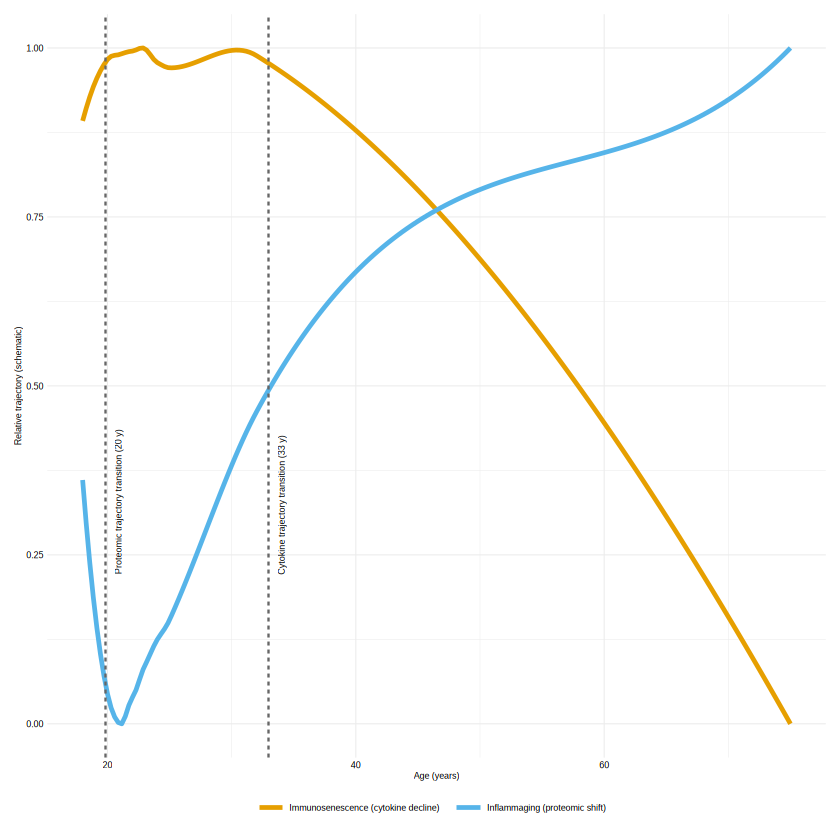

In [14]:
###line should make by itself
Age <- merge_data$Age
# Z-score per column, then row mean (handles different scales across markers)
cyt_score <- rowMeans(scale(cytokine), na.rm = TRUE)
prot_score <- rowMeans(scale(protein), na.rm = TRUE)
df1 <- data.frame(Age, cyt_score, prot_score)
df1 <- df1[complete.cases(df1), ]

# LOESS fit (span: larger = smoother, default 0.75)
fit_cyt <- loess(cyt_score ~ Age, data = df1, span = 0.75)
fit_prot <- loess(prot_score ~ Age, data = df1, span = 0.75)
age_seq <- seq(min(df1$Age), max(df1$Age), length.out = 200)
pred_cyt <- predict(fit_cyt, newdata = data.frame(Age = age_seq))
pred_prot <- predict(fit_prot, newdata = data.frame(Age = age_seq))
# Normalize fitted values to 0-1 for schematic y-axis
pred_cyt_norm <- (pred_cyt - min(pred_cyt)) / diff(range(pred_cyt))
pred_prot_norm <- (pred_prot - min(pred_prot)) / diff(range(pred_prot))

tau_cyt  <- segmented(lm(cyt_score ~ Age, data = df1), seg.Z = ~ Age)$psi[1, 2]
tau_prot <- segmented(lm(prot_score ~ Age, data = df1), seg.Z = ~ Age)$psi[1, 2]

df_plot <- rbind(
  data.frame(Age = age_seq, value = pred_cyt_norm, type = "Immunosenescence (cytokine decline)"),
  data.frame(Age = age_seq, value = pred_prot_norm, type = "Inflammaging (proteomic shift)")
)

p1 <- ggplot(df_plot, aes(x = Age, y = value, color = type)) +
  geom_line(linewidth = 1) +
  geom_vline(xintercept = c(tau_cyt, tau_prot), linetype = 2, color = "gray40") +
 annotate("text", x = tau_cyt+1, y = 0.2, label = paste0("Cytokine trajectory transition (", round(tau_cyt, 0), " y)"), size = 1.8, color = "black",angle = 90,  hjust = -0.1, vjust =0.5) +
  annotate("text", x = tau_prot+1, y = 0.2, label = paste0("Proteomic trajectory transition (", round(tau_prot, 0), " y)"), size = 1.8, color = "black", angle = 90, hjust = -0.1, vjust = 0.5) +
  scale_color_manual(values = c("Inflammaging (proteomic shift)" = "#56B4E9", "Immunosenescence (cytokine decline)" = "#E69F00")) +
  scale_y_continuous(limits = c(0, 1)) +
  labs(x = "Age (years)", y = "Relative trajectory (schematic)", color = NULL) +
  theme_minimal(base_size = 5) +
  theme(
   legend.position = "bottom",
    text = element_text(size = 5),
    axis.title = element_text(size = 5),
    axis.text = element_text(size = 5, color = "black"),
    axis.text.y = element_text(size = 5, color = "black"),
    legend.text = element_text(size = 5),
    legend.title = element_text(size = 5),
       plot.margin = margin(3, 3, 3, 3, "mm") 
  ) +
  guides(color = guide_legend(ncol = 2))  # vertical legend (stacked)
ggsave("/vol/projects/yzhang/500FG_aging/output/14_AA/immune_aging_trajectory_calculated_gender.pdf", p1, width = 80, height = 70, units = "mm")
p1


In [15]:
save.image("/vol/projects/yzhang/500FG_aging/output/14_AA/immune_aging_trajectory_calculated_gender.Rdata")

Cytokine layer transition timepoint: 33.84 years
Protein layer transition timepoint : 19.8 years


Warning message:
“No shared levels found between `names(values)` of the manual scale and the data's colour values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the data's colour values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the data's colour values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the data's colour values.”


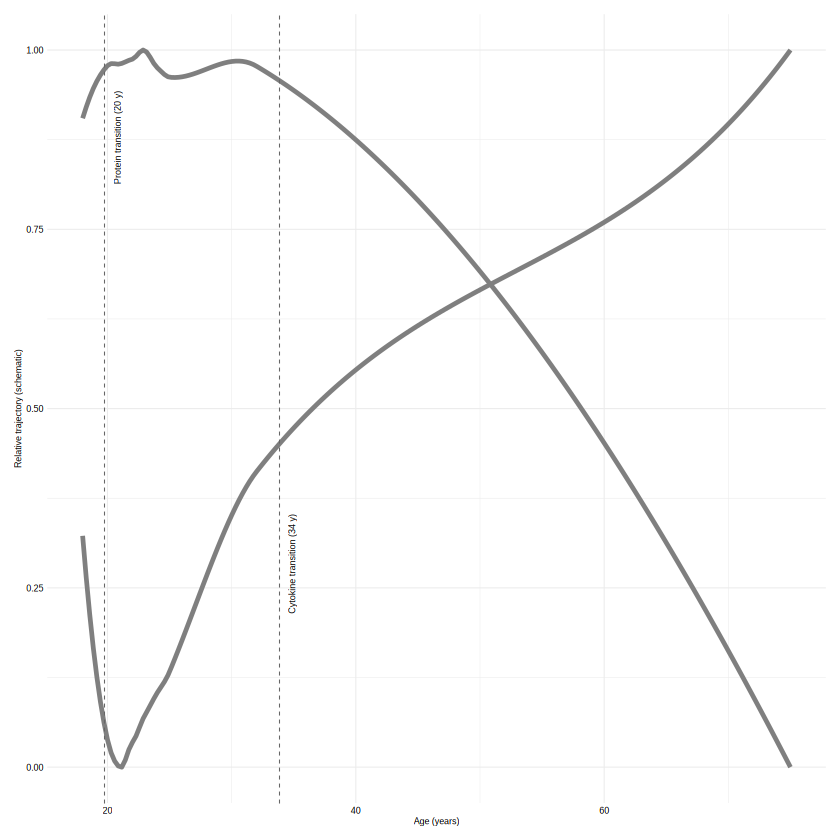

In [18]:
### layer-specific DE-SWAN transition point
Age <- merge_data$Age

# Ensure numeric matrix for both layers
cytokine <- as.data.frame(lapply(cytokine, as.numeric))
protein  <- as.data.frame(lapply(protein,  as.numeric))

# Layer-specific DE-SWAN proportions per sample
# If values are already proportions (or 0/1 DE flags), rowMeans is appropriate.
# If your values are not proportions, set use_binarize = TRUE and tune de_threshold.
use_binarize <- FALSE
de_threshold <- 0

cyt_prop <- if (use_binarize) {
  rowMeans(abs(as.matrix(cytokine)) > de_threshold, na.rm = TRUE)
} else {
  rowMeans(as.matrix(cytokine), na.rm = TRUE)
}

prot_prop <- if (use_binarize) {
  rowMeans(abs(as.matrix(protein)) > de_threshold, na.rm = TRUE)
} else {
  rowMeans(as.matrix(protein), na.rm = TRUE)
}

df1 <- data.frame(Age, cyt_prop, prot_prop)
df1 <- df1[complete.cases(df1), ]

# Helper to extract segmented breakpoint robustly
get_tau <- function(y, x) {
  fit_lm <- lm(y ~ x)
  fit_seg <- segmented(fit_lm, seg.Z = ~x, psi = median(x, na.rm = TRUE))
  if ("Est." %in% colnames(fit_seg$psi)) {
    as.numeric(fit_seg$psi[1, "Est."])
  } else {
    as.numeric(fit_seg$psi[1, 2])
  }
}

# LOESS trajectories
age_seq <- seq(min(df1$Age), max(df1$Age), length.out = 200)
fit_cyt  <- loess(cyt_prop  ~ Age, data = df1, span = 0.75)
fit_prot <- loess(prot_prop ~ Age, data = df1, span = 0.75)

pred_cyt  <- predict(fit_cyt,  newdata = data.frame(Age = age_seq))
pred_prot <- predict(fit_prot, newdata = data.frame(Age = age_seq))

# Normalize to 0-1 for schematic y-axis
norm01 <- function(x) {
  r <- range(x, na.rm = TRUE)
  d <- diff(r)
  if (!is.finite(d) || d == 0) return(rep(0.5, length(x)))
  (x - r[1]) / d
}
pred_cyt_norm  <- norm01(pred_cyt)
pred_prot_norm <- norm01(pred_prot)

# Transition timepoints (layer-specific)
tau_cyt  <- get_tau(df1$cyt_prop,  df1$Age)
tau_prot <- get_tau(df1$prot_prop, df1$Age)

cat("Cytokine layer transition timepoint:", round(tau_cyt, 2), "years\n")
cat("Protein layer transition timepoint :", round(tau_prot, 2), "years\n")

df_plot <- rbind(
  data.frame(Age = age_seq, value = pred_cyt_norm,  type = "Cytokine layer"),
  data.frame(Age = age_seq, value = pred_prot_norm, type = "Protein layer")
)

p1 <- ggplot(df_plot, aes(x = Age, y = value, color = type)) +
  geom_line(linewidth = 1) +
  geom_vline(xintercept = c(tau_cyt, tau_prot), linetype = 2, color = "gray40") +
  annotate("text", x = tau_cyt + 1, y = 0.20,
           label = paste0("Cytokine transition (", round(tau_cyt, 0), " y)"),
           size = 1.8, color = "black", angle = 90, hjust = -0.1, vjust = 0.5) +
  annotate("text", x = tau_prot + 1, y = 0.80,
           label = paste0("Protein transition (", round(tau_prot, 0), " y)"),
           size = 1.8, color = "black", angle = 90, hjust = -0.1, vjust = 0.5) +
  scale_color_manual(values = c("Cytokine layer" = "#E69F00", "Protein layer" = "#56B4E9")) +
  scale_y_continuous(limits = c(0, 1)) +
  labs(x = "Age (years)", y = "Relative trajectory (schematic)", color = NULL) +
  theme_minimal(base_size = 5) +
  theme(
    legend.position = "bottom",
    text = element_text(size = 5),
    axis.title = element_text(size = 5),
    axis.text = element_text(size = 5, color = "black"),
    axis.text.y = element_text(size = 5, color = "black"),
    legend.text = element_text(size = 5),
    legend.title = element_text(size = 5),
    plot.margin = margin(3, 3, 3, 3, "mm")
  ) +
  guides(color = guide_legend(ncol = 2))

ggsave(
  "/vol/projects/yzhang/500FG_aging/output/14_AA/immune_aging_trajectory_DE-SWAN.pdf",
  p1, width = 80, height = 70, units = "mm"
)

p1

Cytokine transition: 49.76 years
Protein transition : 57.5 years


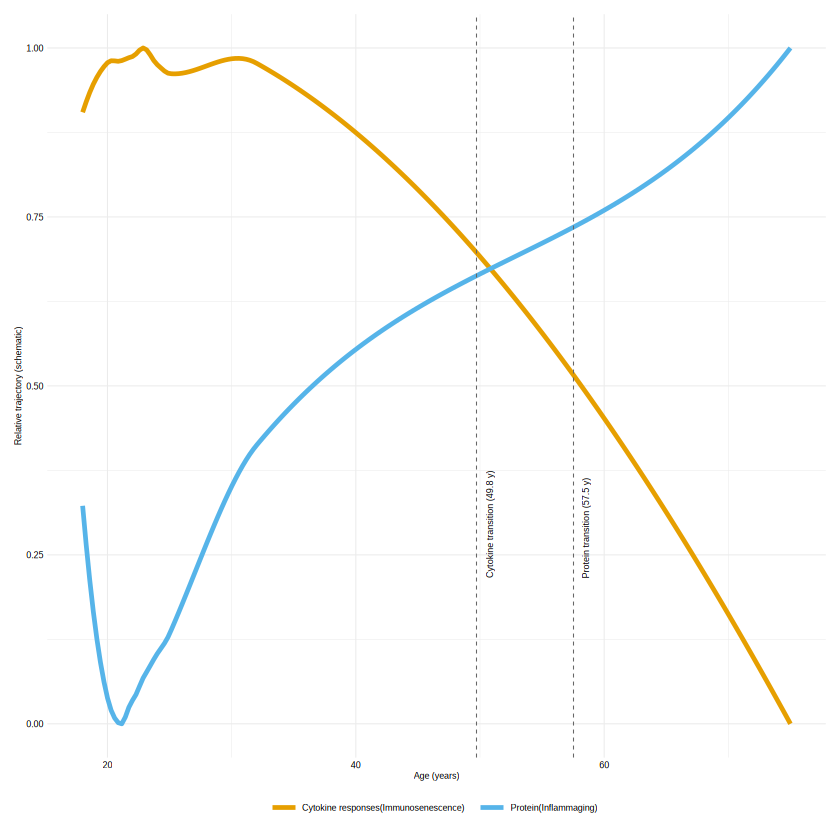

In [19]:
Age <- merge_data$Age

# 1) Prepare numeric matrices
cytokine <- as.data.frame(lapply(cytokine, as.numeric))
protein  <- as.data.frame(lapply(protein,  as.numeric))

# 2) Z-score each feature to match heatmap-style pattern extraction
cyt_z  <- scale(as.matrix(cytokine))
prot_z <- scale(as.matrix(protein))

# 3) Age binning (5-year bins)
bin_width <- 5
age_min <- floor(min(Age, na.rm = TRUE) / bin_width) * bin_width
age_max <- ceiling(max(Age, na.rm = TRUE) / bin_width) * bin_width
breaks <- seq(age_min, age_max, by = bin_width)

df_age <- data.frame(Age = Age) |>
  mutate(bin = cut(Age, breaks = breaks, include.lowest = TRUE, right = FALSE))

# 4) Build bin-level trajectory per layer
get_bin_traj <- function(zmat, df_age) {
  split_idx <- split(seq_len(nrow(df_age)), df_age$bin)
  split_idx <- split_idx[sapply(split_idx, length) >= 5]  # minimum bin size

  centers <- sapply(names(split_idx), function(b) {
    lr <- as.numeric(gsub("\\[|\\)|\\]|\\(", "", unlist(strsplit(b, ","))))
    mean(lr)
  })

  n_bin <- sapply(split_idx, length)

  # Mean expression per feature in each age bin
  # Then summarize to one layer score per bin (mean across features)
  layer_score <- sapply(split_idx, function(ix) {
    feat_means <- colMeans(zmat[ix, , drop = FALSE], na.rm = TRUE)
    mean(feat_means, na.rm = TRUE)
  })

  data.frame(Age = as.numeric(centers), score = as.numeric(layer_score), n = as.numeric(n_bin))
}

traj_cyt  <- get_bin_traj(cyt_z, df_age)
traj_prot <- get_bin_traj(prot_z, df_age)

# 5) Breakpoint on bin-level trajectory (weighted by bin sample size)
get_tau <- function(traj, psi_init) {
  lm0 <- lm(score ~ Age, data = traj, weights = n)
  seg0 <- segmented(lm0, seg.Z = ~Age, psi = psi_init)
  if ("Est." %in% colnames(seg0$psi)) as.numeric(seg0$psi[1, "Est."]) else as.numeric(seg0$psi[1, 2])
}

# Use your visual prior as initial values
tau_cyt  <- get_tau(traj_cyt,  psi_init = 45)
tau_prot <- get_tau(traj_prot, psi_init = 60)

cat("Cytokine transition:", round(tau_cyt, 2), "years\n")
cat("Protein transition :", round(tau_prot, 2), "years\n")

df_plot <- rbind(
  data.frame(Age = age_seq, value = pred_cyt_norm,  type = "Cytokine responses(Immunosenescence)"),
  data.frame(Age = age_seq, value = pred_prot_norm, type = "Protein(Inflammaging)")
)

p1 <- ggplot(df_plot, aes(x = Age, y = value, color = type)) +
  geom_line(linewidth = 1) +
  geom_vline(xintercept = c(tau_cyt, tau_prot), linetype = 2, color = "gray40") +
  annotate("text", x = tau_cyt + 1, y = 0.20,
           label = paste0("Cytokine transition (", round(tau_cyt, 1), " y)"),
           size = 1.8, color = "black", angle = 90, hjust = -0.1, vjust = 0.5) +
  annotate("text", x = tau_prot + 1, y = 0.20,
           label = paste0("Protein transition (", round(tau_prot, 1), " y)"),
           size = 1.8, color = "black", angle = 90, hjust = -0.1, vjust = 0.5) +
  scale_color_manual(values = c("Cytokine responses(Immunosenescence)" = "#E69F00", "Protein(Inflammaging)" = "#56B4E9")) +
  scale_y_continuous(limits = c(0, 1)) +
  labs(x = "Age (years)", y = "Relative trajectory (schematic)", color = NULL) +
  theme_minimal(base_size = 5) +
  theme(
    legend.position = "bottom",
    text = element_text(size = 5),
    axis.title = element_text(size = 5),
    axis.text = element_text(size = 5, color = "black"),
    axis.text.y = element_text(size = 5, color = "black"),
    legend.text = element_text(size = 5),
    legend.title = element_text(size = 5),
    plot.margin = margin(3, 3, 3, 3, "mm")
  ) +
  guides(color = guide_legend(ncol = 2))

ggsave(
  "/vol/projects/yzhang/500FG_aging/output/14_AA/immune_aging_trajectory_Age_segmented.pdf",
  p1, width = 80, height = 70, units = "mm"
)

p1

In [14]:
print(tau_cyt)
print(tau_prot)

[1] 49.75523
[1] 57.49998


Warning message:
“Breakpoint estimate(s) outdistanced to allow finite estimates and st.errs”
Warning message:
“Breakpoint estimate(s) outdistanced to allow finite estimates and st.errs”
Warning message:
“Breakpoint estimate(s) outdistanced to allow finite estimates and st.errs”
Warning message:
“Breakpoint estimate(s) outdistanced to allow finite estimates and st.errs”
Warning message:
“Breakpoint estimate(s) outdistanced to allow finite estimates and st.errs”
Warning message:
“Breakpoint estimate(s) outdistanced to allow finite estimates and st.errs”
Warning message:
“Breakpoint estimate(s) outdistanced to allow finite estimates and st.errs”


Cytokine layer transition timepoint (binned): 51.82 years
Protein layer transition timepoint (binned) : 22.5 years


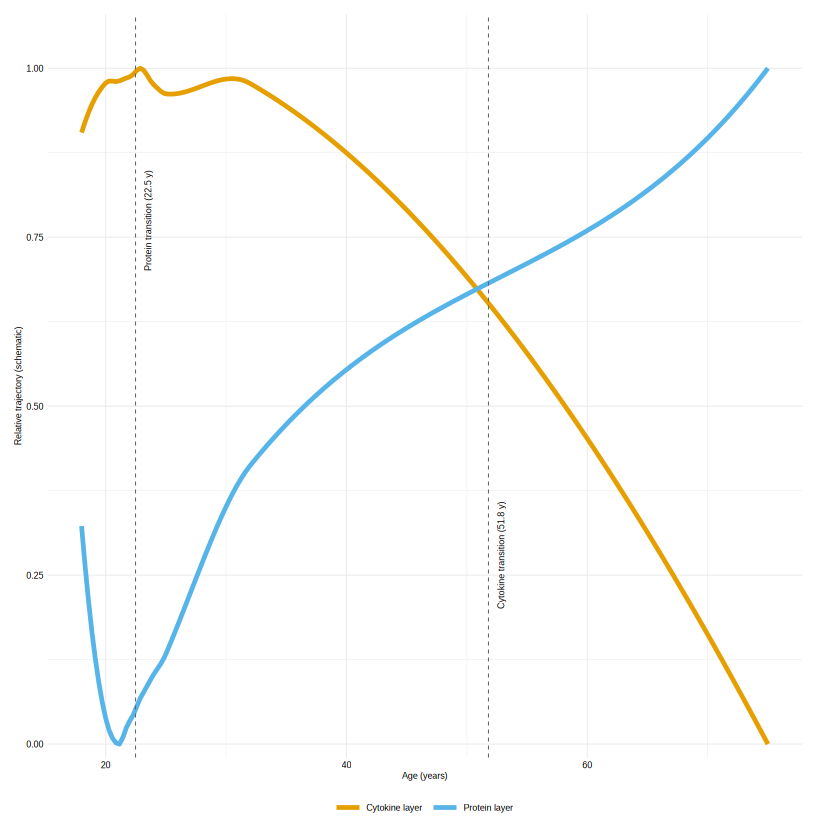

In [15]:
Age <- merge_data$Age
# 1) Prepare numeric matrices
cytokine <- as.data.frame(lapply(cytokine, as.numeric))
protein  <- as.data.frame(lapply(protein,  as.numeric))
# 2) Sample-level proportions for plotting the two smooth lines
cyt_prop  <- rowMeans(as.matrix(cytokine), na.rm = TRUE)
prot_prop <- rowMeans(as.matrix(protein),  na.rm = TRUE)
df1 <- data.frame(Age = Age, cyt_prop = cyt_prop, prot_prop = prot_prop)
df1 <- df1[complete.cases(df1), ]
# 3) Build age-binned trajectory for breakpoint estimation
get_bin_traj <- function(age, y, bin_width = 5, min_n = 5) {
  age_min <- floor(min(age, na.rm = TRUE) / bin_width) * bin_width
  age_max <- ceiling(max(age, na.rm = TRUE) / bin_width) * bin_width
  breaks <- seq(age_min, age_max, by = bin_width)
  d <- data.frame(Age = age, score = y)
  d <- d[complete.cases(d), ]
  d$bin <- cut(d$Age, breaks = breaks, include.lowest = TRUE, right = FALSE)
  sp <- split(d, d$bin)
  sp <- sp[sapply(sp, nrow) >= min_n]
  if (length(sp) < 4) return(data.frame(Age = numeric(), score = numeric(), n = numeric()))
  centers <- sapply(names(sp), function(b) {
    lr <- as.numeric(gsub("\\[|\\)|\\]|\\(", "", unlist(strsplit(b, ","))))
    mean(lr)
  })
  data.frame(
    Age = as.numeric(centers),
    score = sapply(sp, function(x) mean(x$score, na.rm = TRUE)),
    n = sapply(sp, nrow)
  )
}
traj_cyt  <- get_bin_traj(df1$Age, df1$cyt_prop,  bin_width = 5, min_n = 5)
traj_prot <- get_bin_traj(df1$Age, df1$prot_prop, bin_width = 5, min_n = 5)
# 4) Automatic initialization for segmented breakpoint
get_tau_auto <- function(traj) {
  traj <- traj[is.finite(traj$Age) & is.finite(traj$score) & is.finite(traj$n), ]
  if (nrow(traj) < 6) return(NA_real_)
  lm0 <- lm(score ~ Age, data = traj, weights = n)
  psi_grid <- unique(as.numeric(quantile(
    traj$Age, probs = seq(0.2, 0.8, by = 0.1), na.rm = TRUE
  )))
  fits <- lapply(psi_grid, function(p0) {
    tryCatch(segmented(lm0, seg.Z = ~Age, psi = p0), error = function(e) NULL)
  })
  fits <- Filter(Negate(is.null), fits)
  if (length(fits) == 0) return(NA_real_)
  best_fit <- fits[[which.min(sapply(fits, AIC))]]
  if ("Est." %in% colnames(best_fit$psi)) {
    as.numeric(best_fit$psi[1, "Est."])
  } else {
    as.numeric(best_fit$psi[1, 2])
  }
}
tau_cyt  <- get_tau_auto(traj_cyt)
tau_prot <- get_tau_auto(traj_prot)
cat("Cytokine layer transition timepoint (binned):", round(tau_cyt, 2), "years\n")
cat("Protein layer transition timepoint (binned) :", round(tau_prot, 2), "years\n")
# 5) Keep original style: two LOESS lines from sample-level data
age_seq <- seq(min(df1$Age), max(df1$Age), length.out = 200)
fit_cyt  <- loess(cyt_prop ~ Age,  data = df1, span = 0.75)
fit_prot <- loess(prot_prop ~ Age, data = df1, span = 0.75)
pred_cyt  <- predict(fit_cyt,  newdata = data.frame(Age = age_seq))
pred_prot <- predict(fit_prot, newdata = data.frame(Age = age_seq))
norm01 <- function(x) {
  r <- range(x, na.rm = TRUE)
  d <- diff(r)
  if (!is.finite(d) || d == 0) return(rep(0.5, length(x)))
  (x - r[1]) / d
}
pred_cyt_norm  <- norm01(pred_cyt)
pred_prot_norm <- norm01(pred_prot)
df_plot <- rbind(
  data.frame(Age = age_seq, value = pred_cyt_norm,  type = "Cytokine layer"),
  data.frame(Age = age_seq, value = pred_prot_norm, type = "Protein layer")
)
p1 <- ggplot(df_plot, aes(x = Age, y = value, color = type)) +
  geom_line(linewidth = 1) +
  geom_vline(xintercept = c(tau_cyt, tau_prot), linetype = 2, color = "gray40") +
  annotate("text", x = tau_cyt + 1, y = 0.20,
           label = paste0("Cytokine transition (", sprintf("%.1f", tau_cyt), " y)"),
           size = 1.8, color = "black", angle = 90, hjust = 0, vjust = 0.5) +
  annotate("text", x = tau_prot + 1, y = 0.70,
           label = paste0("Protein transition (", sprintf("%.1f", tau_prot), " y)"),
           size = 1.8, color = "black", angle = 90, hjust = 0, vjust = 0.5) +
  scale_color_manual(values = c("Cytokine layer" = "#E69F00", "Protein layer" = "#56B4E9")) +
  scale_y_continuous(limits = c(0, 1), expand = expansion(mult = c(0.02, 0.08))) +
  coord_cartesian(clip = "off") +
  labs(x = "Age (years)", y = "Relative trajectory (schematic)", color = NULL) +
  theme_minimal(base_size = 5) +
  theme(
    legend.position = "bottom",
    text = element_text(size = 5),
    axis.title = element_text(size = 5),
    axis.text = element_text(size = 5, color = "black"),
    axis.text.y = element_text(size = 5, color = "black"),
    legend.text = element_text(size = 5),
    legend.title = element_text(size = 5),
    plot.margin = margin(3, 8, 3, 3, "mm")
  ) +
  guides(color = guide_legend(ncol = 2))
ggsave(
  "/vol/projects/yzhang/500FG_aging/output/14_AA/immune_aging_trajectory_Age_binned_segmented_auto.pdf",
  p1, width = 80, height = 70, units = "mm"
)
p1
